# Assignment 1. Data Manipulation and Visualization  

*Foundations of Data Science*  
*Dr. Khalaj (Fall 2024)*  



### Description
In this homework you are supposed to get comfortable (or make sure that you are!) with the basic Python tools frequently used in data science.  

### Information  
Complete the information box below.

In [1]:
full_name = "Rouzbeh Pourjafarian"
student_id = "400106279"

### Import necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as ss
import re
import string
import sqlite3
import random

# ====================================
# feel free to import any other package
# ====================================

# 1. Let's Talk Business!

Storing customer and transaction data is crucial for e-commerce businesses as it enables them to understand and anticipate customer needs, optimize operations, and enhance the overall shopping experience. By collecting and analyzing data such as purchase history, browsing behavior, and demographic information, e-commerce platforms can personalize marketing efforts, recommend products, and improve customer retention. Additionally, transaction data helps in managing inventory, detecting fraudulent activities, and ensuring secure payment processing

This dataset contains the official transactions and customer data for a certain E-Commerce. The schema of the dataset can be shown in the following diagram.

<div style="text-align: center;">
<img src="./data/Q1/commerce_schema.png" alt="commerce-schema" width="750"/>
</div>

In this task you have to apply the following Data Wrangling pipeline:
* Load your data into `Pandas`  

* Explore it and clean its dirty parts
* Use it to answer a set of queries

Each of these subtasks are described in detail below.

## 1.1 Loading Phase

Load all of the sheets in the excel file to multiple `Pandas` dataframes in the directory `data/Q1`

In [4]:
customers = pd.read_excel('data/Q1/E-commerce_data.xlsx','customers')
customers

,customer_id,join_date,city_id,gender_id
0,1,2022-01-08,7,1
1,2,2023-05-02,20,2
2,3,2023-05-14,15,1
3,4,2022-11-25,11,2
4,5,2023-04-26,8,1
...,...,...,...,...
995,996,2022-10-28,3,1
996,997,2022-07-07,20,2
997,998,2024-03-09,11,2
998,999,2022-07-16,6,1


In [5]:
genders = pd.read_excel('data/Q1/E-commerce_data.xlsx','genders')
genders

,gender_id,gender_name
0,1,Male
1,2,Female


In [6]:
cities = pd.read_excel('data/Q1/E-commerce_data.xlsx','cities')
cities

,city_id,city_name
0,1,Cairo
1,2,Alexandria
2,3,Giza
3,4,Shubra El-Kheima
4,5,Port Said
5,6,Suez
6,7,Mansoura
7,8,El-Mahalla El-Kubra
8,9,Tanta
9,10,Asyut


In [7]:
transactions = pd.read_excel('data/Q1/E-commerce_data.xlsx','transactions')
transactions

,Unnamed: 0,transaction_id,customer_id,transaction_date,transaction_status,coupon_name,burn_date,branch_id
0,0,1,733,2024-05-11,subscribed,uNY-568,NaT,7.0
1,1,2,631,2023-05-15,burned,kBx-219,2023-06-04,5.0
2,2,3,309,2022-11-13,subscribed,PLG-122,NaT,7.0
3,3,4,695,20240-01-26,subscribed,Wzf-897,NaT,2.0
4,4,5,288,2022-10-12,burned,qGb-428,2022-11-20,6.0
...,...,...,...,...,...,...,...,...
4995,4995,4996,776,2024-03-20,subscribed,OSq-518,NaT,1.0
4996,4996,4997,583,2024-06-27,subscribed,FsJ-607,NaT,2.0
4997,4997,4998,504,2022-11-08,burned,WcY-330,2022-12-06,2.0
4998,4998,4999,876,2024-05-05,burned,bgx-731,2024-07-29,7.0


In [8]:
branches = pd.read_excel('data/Q1/E-commerce_data.xlsx','branches')
branches

,branch_id,merchant_id
0,1,11
1,2,18
2,3,8
3,4,15
4,5,9
5,6,15
6,7,7
7,8,20
8,9,13
9,10,13


In [9]:
merchants = pd.read_excel('data/Q1/E-commerce_data.xlsx','merchants')
merchants

,merchant_id,merchant_name
0,1,Rivas Group
1,2,Peters-Acosta
2,3,"Duran, Perry and Stout"
3,4,Morton Ltd
4,5,Curtis-Fields
5,6,Armstrong-Gutierrez
6,7,Berry-Anderson
7,8,Medina-Foster
8,9,"Campbell, Shaffer and Martinez"
9,10,"Adams, Cruz and Williams"


## 1.2 Cleaning Phase

Explore the following columns from your dataset:

* transactions: year  

* transactions: branch_id
  
Answer the following questions using data visualizations and manipulations. The code for this part is required alongside your explanations either in comments or markdown.  

1. What is the time range of the transactions?  
2. What is the median branch in terms of transaction count?
3. Do you see any inconsistencies? 
4. Provide code that detects and cleans such inconsistencies and validates the coherence of your dataset. 

By using transactions from previous section, import [transaction_date] and [branch_id] columns

In [10]:
# 1. What is the time range of the transactions?  

# Import DataBase
df = transactions
df

# Function to check if a date is valid
def is_valid_date(date_str):
    try:
        # Attempt to convert the string to a datetime object
        pd.to_datetime(date_str)
        return True
    except ValueError:
        return False

# Filter out rows with invalid dates
df['is_valid_date'] = df['transaction_date'].apply(is_valid_date)
filtered_df = df[df['is_valid_date']]

# Drop the temporary 'is_valid_date' column
filtered_df = filtered_df.drop(columns=['is_valid_date'])
transactions_valid_dates = filtered_df

# Convert the column to datetime format
transactions_valid_dates['transaction_date'] = pd.to_datetime(transactions_valid_dates['transaction_date'])

# Calculate the date range
date_range = transactions_valid_dates['transaction_date'].max() - transactions_valid_dates['transaction_date'].min()
date_first = transactions_valid_dates['transaction_date'].min()
date_last = transactions_valid_dates['transaction_date'].max()
print(f"Date range: {date_range} from {date_first} to {date_last}")

Date range: 1074 days 00:00:00 from 2021-08-05 00:00:00 to 2024-07-14 00:00:00


In [11]:
# 2. What is the median branch in terms of transaction count?
branch_counts = transactions.branch_id.value_counts().sort_index()
median_branch_count = branch_counts.median()
median_branch_count
print(f"Median is {median_branch_count}.")

Median is 493.5.


In [12]:
# 3. Do you see any inconsistencies? 
# There are some outliers such as 20240-01-26.

In [13]:
# 4. Provide code that detects and cleans such inconsistencies and validates the coherence of your dataset.

df = transactions
df
# Function to check if a date is valid
def is_valid_date(date_str):
    try:
        # Attempt to convert the string to a datetime object
        pd.to_datetime(date_str)
        return True
    except ValueError:
        return False

# Filter out rows with invalid dates
df['is_valid_date'] = df['transaction_date'].apply(is_valid_date)
filtered_df = df[df['is_valid_date']]

# Drop the temporary 'is_valid_date' column
filtered_df = filtered_df.drop(columns=['is_valid_date'])
transactions_valid_dates = filtered_df

# Sort by Date
transactions_valid_dates_sort = transactions_valid_dates.sort_values('transaction_date')
transactions_valid_dates_sort

,Unnamed: 0,transaction_id,customer_id,transaction_date,transaction_status,coupon_name,burn_date,branch_id
67,67,68,246,2021-08-05,burned,UzK-359,2021-08-14,7.0
2607,2607,2608,728,2021-08-19,subscribed,qOJ-594,NaT,4.0
1712,1712,1713,727,2021-08-29,burned,Yhh-771,2021-09-30,6.0
1787,1787,1788,661,2021-09-01,subscribed,VJN-120,NaT,1.0
3503,3503,3504,802,2021-09-07,burned,Jxp-154,2021-11-16,3.0
...,...,...,...,...,...,...,...,...
3672,3672,3673,726,2024-07-14,subscribed,AUU-306,NaT,6.0
4263,4263,4264,734,2024-07-14,burned,xyh-145,2024-07-20,3.0
3652,3652,3653,829,2024-07-14,subscribed,ejp-469,NaT,9.0
21,21,22,35,2024-07-14,subscribed,MGf-702,NaT,8.0


**Explain your approach and assumptions once this section is completed.**

After extracting the desired file and columns, 
Optionally, we check whether there are inconsistent values ​​of the date. We check this by converting the data in the date column to the date format, YYYY-MM-DD. After doing this, we sort the dates and obtain the time interval from the maximum and minimum values.

## 1.3. Querying phase

Answer the following queries using the functionality of `Pandas`:

* List the names of the cities of customers who have spent coupons ending with a number less than 100. (*Hint: Find a smart way to distinguish which coupons contain numbers less than 100*).  

* Plot the distribution of merchants' transactions as a (horizontal) bar chart. Restrict yourself to the 5 merchants with their names in the x-axis.

* Create a line plot of the mean transaction counts in a month, through time. add an area plot on top of the line plot depicting the minimum and maximum bounds in each month.

* Repeat the previous part but categorize the dataset by transcription_status first. Are there any visible trends in the consuming patterns of subscribed vs. burned customers?

In [33]:
# List the names of the cities of customers who have spent coupons ending with a number less than 100. (*Hint: Find a smart way to distinguish which coupons contain numbers less than 100*).  

temp = transactions.merge(customers, on="customer_id", how="left")
temp = temp.merge(genders, on="gender_id", how="left")
temp = temp.merge(cities, on="city_id", how="left")
(temp[temp["coupon_name"].str.split("-").str[1].astype(int) < 100][["city_name"]]).city_name.unique()

array(['Alexandria', 'El-Mahalla El-Kubra', 'Sohag', 'Damietta', 'Tanta',
       'Cairo', 'Beni Suef', 'Fayyum', 'Shubra El-Kheima', 'Qena',
       'Mansoura', 'Minya', 'Damanhur', 'Asyut', 'Ismailia', 'Giza',
       'Suez', 'Aswan', 'Zagazig', 'Port Said'], dtype=object)

**Explain your approach and assumptions once this section is completed.**

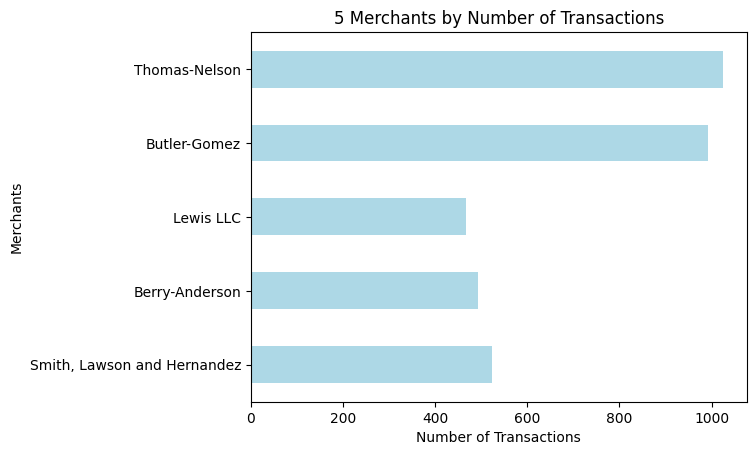

In [34]:
# Plot the distribution of merchants' transactions as a (horizontal) bar chart. Restrict yourself to the 5 merchants with their names in the x-axis.

temp = transactions.merge(branches, on="branch_id", how="left")
temp = temp.merge(merchants, on="merchant_id", how="left")
merchants_counts = temp.merchant_name.value_counts()

# Select 5 random merchants from the unique merchant list
random_merchants = random.sample(list(merchants_counts.index), 5)
# Filter the counts to only include these random 5 merchants
random_5_merchants = merchants_counts.loc[random_merchants]
random_5_merchants.plot(kind='barh', color='lightblue')

# Add labels and title
plt.xlabel('Number of Transactions')
plt.ylabel('Merchants')
plt.title('5 Merchants by Number of Transactions')

# Display the plot
plt.show()

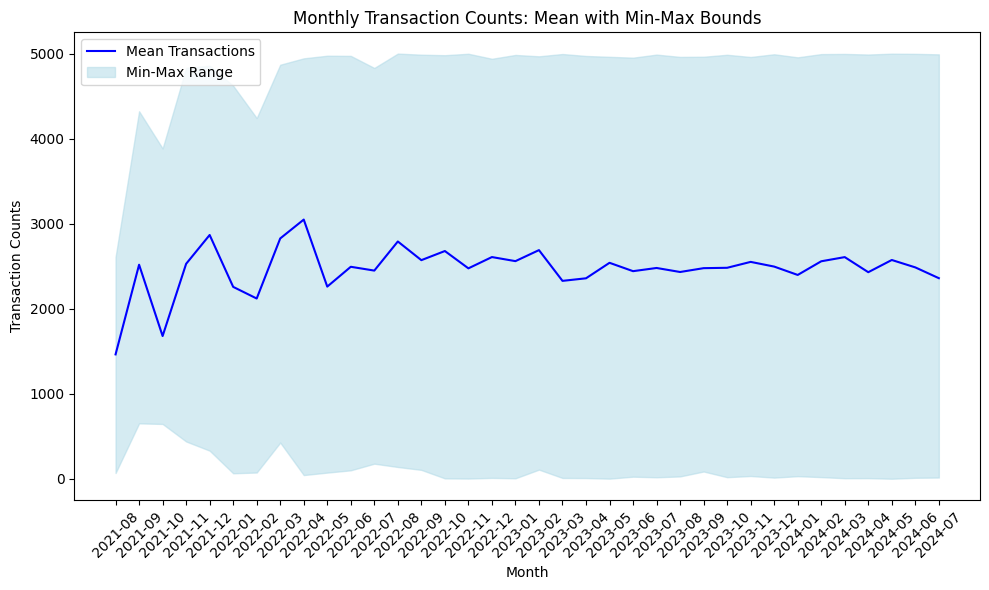

In [200]:
# Create a line plot of the mean transaction counts in a month, through time. add an area plot on top of the line plot depicting the minimum and maximum bounds in each month.

df = transactions_valid_dates

# Convert 'Date' column to datetime if necessary
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract the month from the 'Date' column
df['Month'] = df['transaction_date'].dt.to_period('M')

# Group by month and calculate mean, min, and max transaction counts
monthly_stats = df.groupby('Month')['transaction_id'].agg(['mean', 'min', 'max'])

# Plotting
plt.figure(figsize=(10, 6))

# Line plot for the mean transaction counts
plt.plot(monthly_stats.index.astype(str), monthly_stats['mean'], label='Mean Transactions', color='blue')

# Area plot (shaded region) between the min and max values
plt.fill_between(monthly_stats.index.astype(str), monthly_stats['min'], monthly_stats['max'], color='lightblue', alpha=0.5, label='Min-Max Range')

# Add labels, title, and legend
plt.xlabel('Month')
plt.ylabel('Transaction Counts')
plt.title('Monthly Transaction Counts: Mean with Min-Max Bounds')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

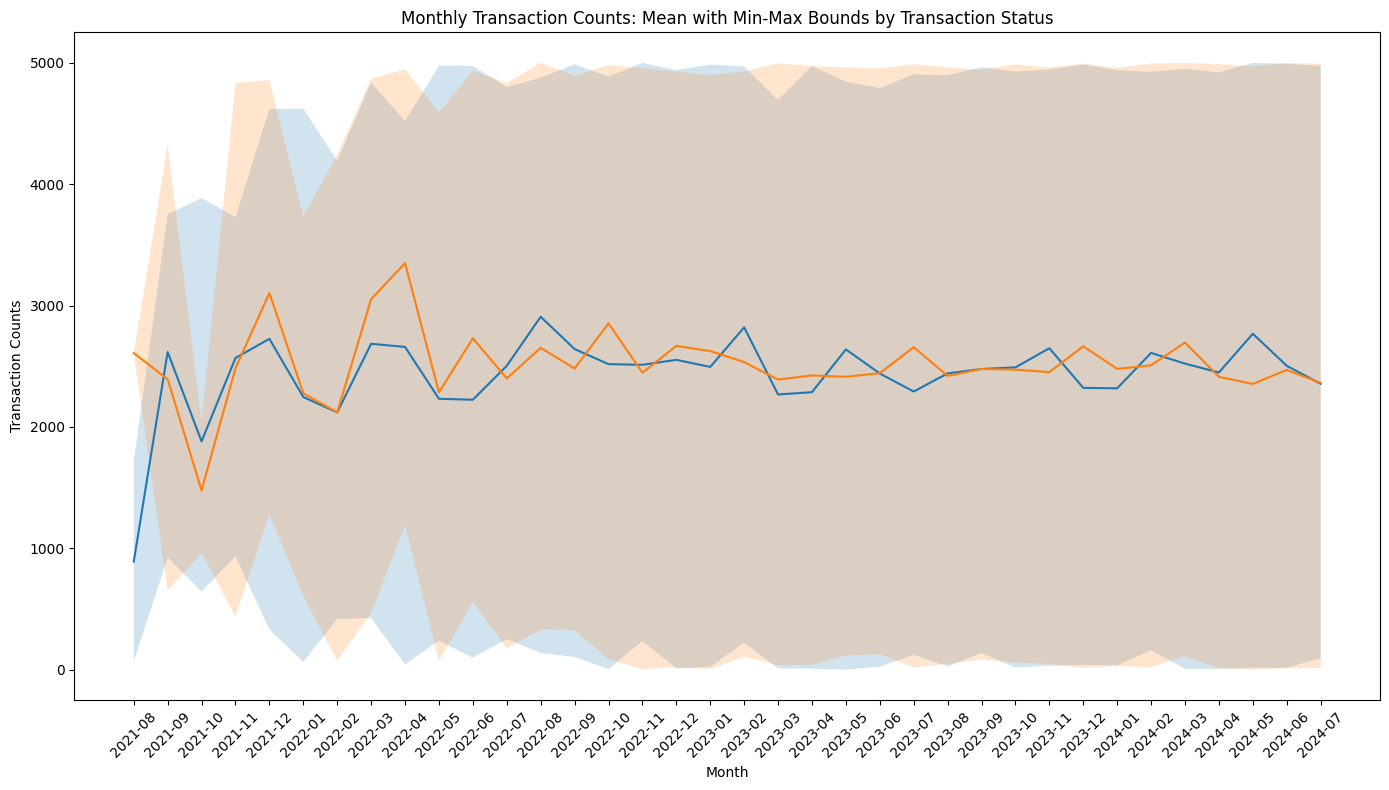

In [17]:
# Repeat the previous part but categorize the dataset by transcription_status first. Are there any visible trends in the consuming patterns of subscribed vs. burned customers?

df = transactions_valid_dates
# Convert 'Date' column to datetime if necessary
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
# Extract the month from the 'Date' column
df['Month'] = df['transaction_date'].dt.to_period('M')


monthly_status = df.groupby(['Month', 'transaction_status'])['transaction_id'].agg(['mean', 'min', 'max']).reset_index()

# Plotting each 'transaction_status' category separately
plt.figure(figsize=(14, 8))

# Separate data for each transaction status and plot
for status in monthly_status['transaction_status'].unique():
    status_data = monthly_status[monthly_status['transaction_status'] == status]
    
    # Line plot for the mean transaction counts for each status
    plt.plot(status_data['Month'].astype(str), status_data['mean'], label=f'Mean Transactions ({status})')
    
    # Area plot for min-max range for each status
    plt.fill_between(status_data['Month'].astype(str), status_data['min'], status_data['max'], alpha=0.2,
                     label=f'Min-Max Range ({status})')

# Add labels, title, and legend
plt.xlabel('Month')
plt.ylabel('Transaction Counts')
plt.title('Monthly Transaction Counts: Mean with Min-Max Bounds by Transaction Status')
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

**Explain your approach and assumptions once this section is completed.**

First, we separated the numerical value at the end of the caps and then checked the values ​​less than 100.
In the next part, we obtained the number of transactions in the month and we did this by separating the month from the given date, and then based on the transaction_id, we drew the median chart and also drew its maximum and minimum intervals.


# 2. Canadian Cheese Directory!

The database of Canadian cheeses made from cow, goat, sheep or buffalo milk has been provided.

In this question you will again perform data wrangling and interpretation.

## 2.1 Loading Phase 

Load the csv file into a `DataFrame`

In [18]:
cheese_data = pd.read_csv('data/Q2/cheese_data.csv')
cheese_data

,Unnamed: 0,CheeseId,ManufacturerProvCode,ManufacturingTypeEn,MoisturePercent,FlavourEn,CharacteristicsEn,Organic,CategoryTypeEn,MilkTypeEn,MilkTreatmentTypeEn,RindTypeEn,CheeseName,FatLevel,FatIndex
0,0,228,NB,Farmstead,47.0,"Sharp, lactic",Uncooked,0,Firm Cheese,Ewe,Raw Milk,Washed Rind,Sieur de Duplessis (Le),lower fat,0
1,1,242,NB,Farmstead,47.9,"Sharp, lactic, lightly caramelized",Uncooked,0,Semi-soft Cheese,Cow,Raw Milk,Washed Rind,Tomme Le Champ Doré,lower fat,0
2,2,301,ON,Industrial,54.0,"Mild, tangy, and fruity","Pressed and cooked cheese, pasta filata, inter...",0,Firm Cheese,Cow,Pasteurized,NaN,Provolone Sette Fette (Tre-Stelle),lower fat,0
3,3,303,NB,Farmstead,47.0,Sharp with fruity notes and a hint of wild honey,NaN,0,Veined Cheeses,Cow,Raw Milk,NaN,Geai Bleu (Le),lower fat,0
4,4,319,NB,Farmstead,49.4,Softer taste,NaN,1,Semi-soft Cheese,Cow,Raw Milk,Washed Rind,Gamin (Le),lower fat,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,1037,2387,NS,Farmstead,37.0,"Dill, Caraway, Chili Pepper, Cumin, Sage, Chiv...",Fresh curds through a variety of added Organic...,1,Hard Cheese,Cow,Pasteurized,NaN,Knoydart,higher fat,1
1038,1038,2388,AB,Industrial,46.0,Mild and Deep Flavor,Low in Sodium and Fat,0,Fresh Cheese,Cow,Pasteurized,NaN,FRESK-O,lower fat,0
1039,1039,2389,NS,Artisan,40.0,Grassy tang and restrained saltiness that refl...,NaN,0,Veined Cheeses,Ewe,Thermised,NaN,Electric Blue,higher fat,1
1040,1040,2390,NS,Artisan,34.0,Sweet and tangy flavours combine with hoppy no...,NaN,0,Semi-soft Cheese,Ewe,Thermised,Washed Rind,Hip Hop,higher fat,1


In [19]:
cheese_data.FatIndex.unique()

array([0, 1])

## 2.2 Cleaning Phase 

Perform the following actions on the dataset.

1. Describe the type and the value range of each attribute.  
2. Indicate and transform the attributes that are `Categorical`.
3. Are there redundant columns in the dataset (i.e., are there columns whose value depends only on the value of another column)?
4. What are the possible pitfalls of having such columns?

Reduce *data redundancy* by extracting such columns to separate `DataFrames`. Which of the two formats (the initial one or the one with reduced data redundancy) is more susceptible to inconsistencies? At the end print for each `Dataframe` the *type of each column* and it's *shape*.

2.2.1. Describe the type and the value range of each attribute.  


In [20]:
# get the data types of each attribute.
cheese_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1042 non-null   int64  
 1   CheeseId              1042 non-null   int64  
 2   ManufacturerProvCode  1042 non-null   object 
 3   ManufacturingTypeEn   1042 non-null   object 
 4   MoisturePercent       1028 non-null   float64
 5   FlavourEn             801 non-null    object 
 6   CharacteristicsEn     643 non-null    object 
 7   Organic               1042 non-null   int64  
 8   CategoryTypeEn        1019 non-null   object 
 9   MilkTypeEn            1041 non-null   object 
 10  MilkTreatmentTypeEn   977 non-null    object 
 11  RindTypeEn            721 non-null    object 
 12  CheeseName            1042 non-null   object 
 13  FatLevel              1042 non-null   object 
 14  FatIndex              1042 non-null   int64  
dtypes: float64(1), int64(

In [21]:
# get the statistical summary of numeric attributes.
cheese_data.describe()

,Unnamed: 0,CheeseId,MoisturePercent,Organic,FatIndex
count,1042.000000,1042.000000,1028.000000,1042.000000,1042.000000
mean,520.500000,1560.633397,47.069747,0.095010,0.343570
std,300.943793,451.811164,9.592647,0.293369,0.475128
min,0.000000,228.000000,12.000000,0.000000,0.000000
25%,260.250000,1280.250000,40.000000,0.000000,0.000000
50%,520.500000,1548.500000,46.000000,0.000000,0.000000
75%,780.750000,1901.750000,52.000000,0.000000,1.000000
max,1041.000000,2391.000000,92.000000,1.000000,1.000000


In [22]:
# describe for categorical data
cheese_data.describe(include=['O'])

,ManufacturerProvCode,ManufacturingTypeEn,FlavourEn,CharacteristicsEn,CategoryTypeEn,MilkTypeEn,MilkTreatmentTypeEn,RindTypeEn,CheeseName,FatLevel
count,1042,1042,801,643,1019,1041,977,721,1042,1042
unique,10,3,635,535,6,8,3,4,1038,2
top,QC,Industrial,Mild,Creamy,Firm Cheese,Cow,Pasteurized,No Rind,Boerenkaas,lower fat
freq,796,455,59,19,349,743,800,404,2,684


In [240]:
min_Percent = cheese_data['MoisturePercent'].min()
max_Percent = cheese_data['MoisturePercent'].max()
range = max_Percent - min_Percent
print(f"MoisturePercent range: {min_Percent} to {max_Percent} ({range})")

MoisturePercent range: 12.0 to 92.0 (80.0)


2.2.2. Indicate and transform the attributes that are `Categorical`.


In [24]:
# Identify and print categorical attributes
categorical_cols = cheese_data.select_dtypes(include=['object']).columns
print("Categorical attributes:", categorical_cols)

# Transform categorical attributes using one-hot encoding
df_encoded = pd.get_dummies(cheese_data, columns=categorical_cols)
df_encoded


Categorical attributes: Index(['ManufacturerProvCode', 'ManufacturingTypeEn', 'FlavourEn',
       'CharacteristicsEn', 'CategoryTypeEn', 'MilkTypeEn',
       'MilkTreatmentTypeEn', 'RindTypeEn', 'CheeseName', 'FatLevel'],
      dtype='object')


,Unnamed: 0,CheeseId,MoisturePercent,Organic,FatIndex,ManufacturerProvCode_AB,ManufacturerProvCode_BC,ManufacturerProvCode_MB,ManufacturerProvCode_NB,ManufacturerProvCode_NL,...,CheeseName_Écume des Rapides (L'),CheeseName_Élan (L') (Fromagerie St-Albert),CheeseName_Élan 7% (L'),CheeseName_Élite (L'),CheeseName_Épave (L'),CheeseName_Étoile Bleue de Saint-Rémi (L'),CheeseName_Étoile de Saint-Raymond L',CheeseName_Évanjules (L'),FatLevel_higher fat,FatLevel_lower fat
0,0,228,47.0,0,0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1,242,47.9,0,0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
2,2,301,54.0,0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,3,303,47.0,0,0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,4,319,49.4,1,0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,1037,2387,37.0,1,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1038,1038,2388,46.0,0,0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1039,1039,2389,40.0,0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1040,1040,2390,34.0,0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


2.2.3. Are there redundant columns in the dataset (i.e., are there columns whose value depends only on the value of another column)?

In [25]:
# Convert non-numeric columns to numeric if possible
df_numeric = cheese_data.select_dtypes(include=[float, int])
df_numeric.corr()


,Unnamed: 0,CheeseId,MoisturePercent,Organic,FatIndex
Unnamed: 0,1.000000,0.980996,-0.015327,-0.030536,-0.005549
CheeseId,0.980996,1.000000,-0.009948,-0.037155,-0.008712
MoisturePercent,-0.015327,-0.009948,1.000000,-0.114607,-0.495421
Organic,-0.030536,-0.037155,-0.114607,1.000000,0.082607
FatIndex,-0.005549,-0.008712,-0.495421,0.082607,1.000000


2.2.4. What are the possible pitfalls of having such columns?

In [ ]:
# Having redundant columns in dataset can create several pitfalls:

# 1. Increased Complexity: More columns mean more complexity in data analysis, making it harder to draw clear insights.
# 2. Overfitting in Models: Redundant columns can cause overfitting in machine learning models, where the model performs well on training data but poorly on unseen data.
# 3. Inefficient Computation: Extra, unnecessary data increases computation time and resources.
# 4. Collinearity Issues: Highly correlated columns can lead to multicollinearity, causing instability in model coefficients and making it difficult to understand the importance of each feature.
# 5. Misleading Analysis: Redundant information can mislead statistical analysis, leading to incorrect conclusions.

In [32]:
# Selecting one-hot encoded columns that represent mutually exclusive categories by design

categorical_columns = cheese_data.select_dtypes(include=['object']).columns
cheese_data_encoded = pd.get_dummies(cheese_data, columns=categorical_columns)

redundant_columns = [
    col for col in cheese_data_encoded.columns 
    if ("ManufacturerProvCode" in col or "ManufacturingTypeEn" in col or "FlavourEn" in col)
]

# Creating two DataFrames
core_df = cheese_data_encoded.drop(columns=redundant_columns)
redundant_df = cheese_data_encoded[redundant_columns]

# Checking column types and shapes
core_df_info = core_df.dtypes, core_df.shape
redundant_df_info = redundant_df.dtypes, redundant_df.shape

core_df_info, redundant_df_info

((Unnamed: 0                                      int64
  CheeseId                                        int64
  MoisturePercent                               float64
  Organic                                         int64
  FatIndex                                        int64
                                                 ...   
  CheeseName_Étoile Bleue de Saint-Rémi (L')       bool
  CheeseName_Étoile de Saint-Raymond L'            bool
  CheeseName_Évanjules (L')                        bool
  FatLevel_higher fat                              bool
  FatLevel_lower fat                               bool
  Length: 1601, dtype: object,
  (1042, 1601)),
 (ManufacturerProvCode_AB                                                                                                                                 bool
  ManufacturerProvCode_BC                                                                                                                                 bool
  ManufacturerProv

**Explain your approach and assumptions once this section is completed.**

We obtained the requested information by using the info and describe commands, and then we checked the degree of dependence between 1 and -1 with the correlation command.


## 2.3 Querying Phase

Answer the following queries using the functionality of `Pandas`.

* Plot the **proportion** of **ManufacturingTypeEn**, **MoisturePercent**, **CategoryTypeEn**, **MilkTypeEn** columns in four subplots using pie diagrams.

* Categorize the dataframe by the **FatIndex**. Calculate the proportion of each FatIndex in the previous columns (ManufacturingTypeEn, MoisturePercent, CategoryTypeEn, MilkTypeEn) and present your results in a **stacked bar chart**.

* Separate the MoisturePercent values into two intervals that have (approximately) the same number of cheese products in the dataset. Categorize the dataset based on MoistureIndex, FatIndex, ManufacturingTypeEn, MoisturePercent, CategoryTypeEn, MilkTypeEn and calculate the proportions of each category. Represent your results in a separate `DataFrame`.

* Is there any row that is slightly more popular than the others? Do you see any correlation between the cheese attributes and their popularity?


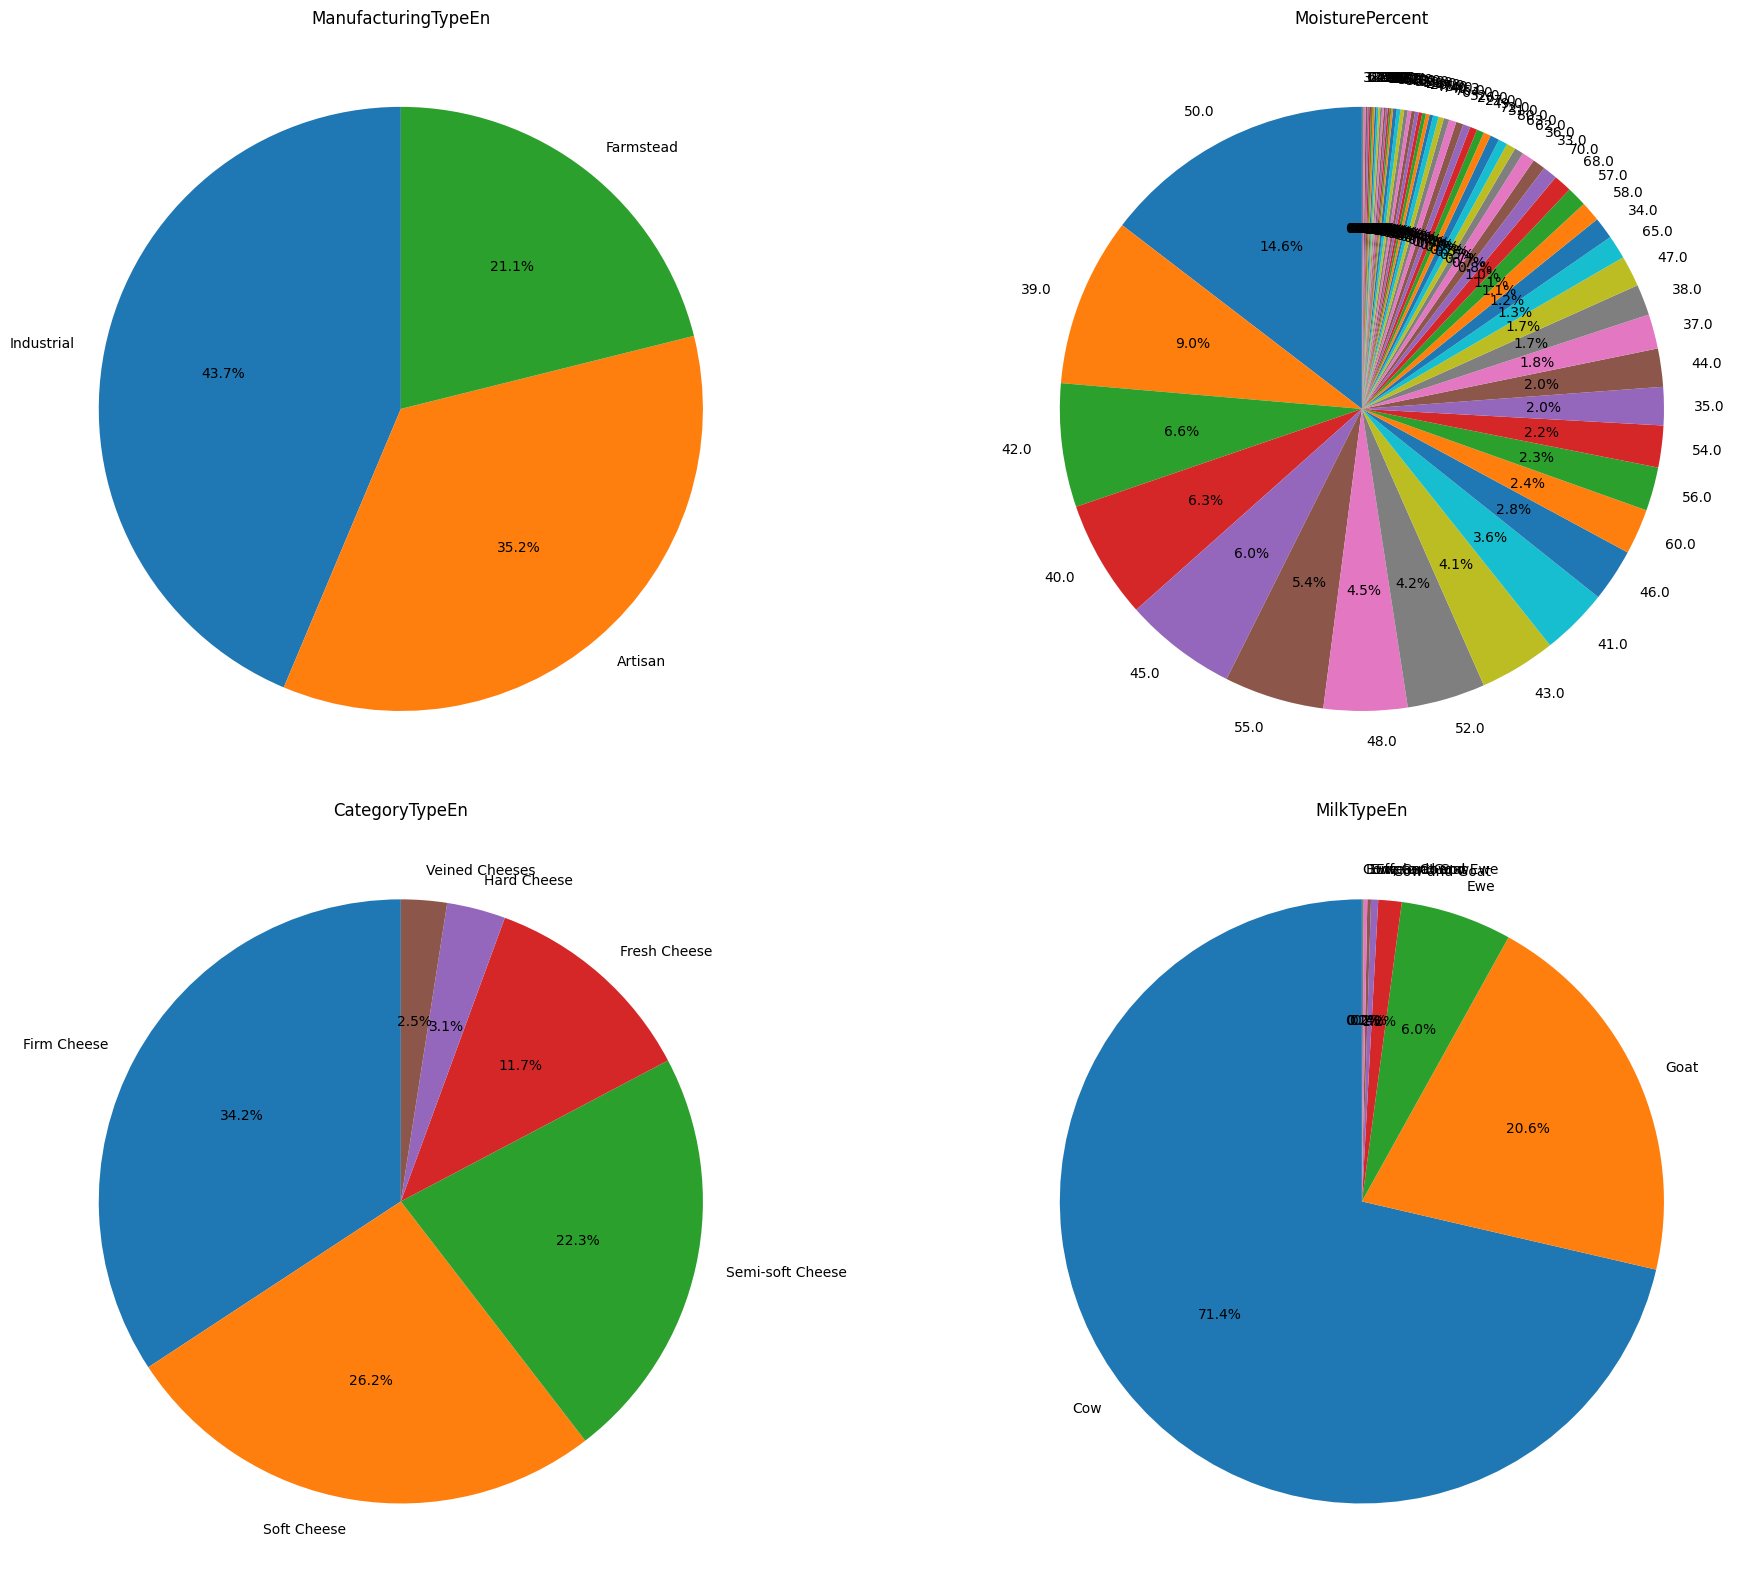

In [37]:
# * Plot the proportion of ManufacturingTypeEn, MoisturePercent, CategoryTypeEn, MilkTypeEn columns in four subplots using pie diagrams.

# Define the columns to plot
columns_to_plot = ['ManufacturingTypeEn', 'MoisturePercent', 'CategoryTypeEn', 'MilkTypeEn']

# Create a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

# Flatten the array of axes for easy iteration
axs = axs.flatten()

# Plot each column as a pie chart
for i, column in enumerate(columns_to_plot):
    cheese_data[column].value_counts().plot.pie(ax=axs[i], autopct='%1.1f%%', startangle=90)
    axs[i].set_title(column)
    axs[i].set_ylabel('')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


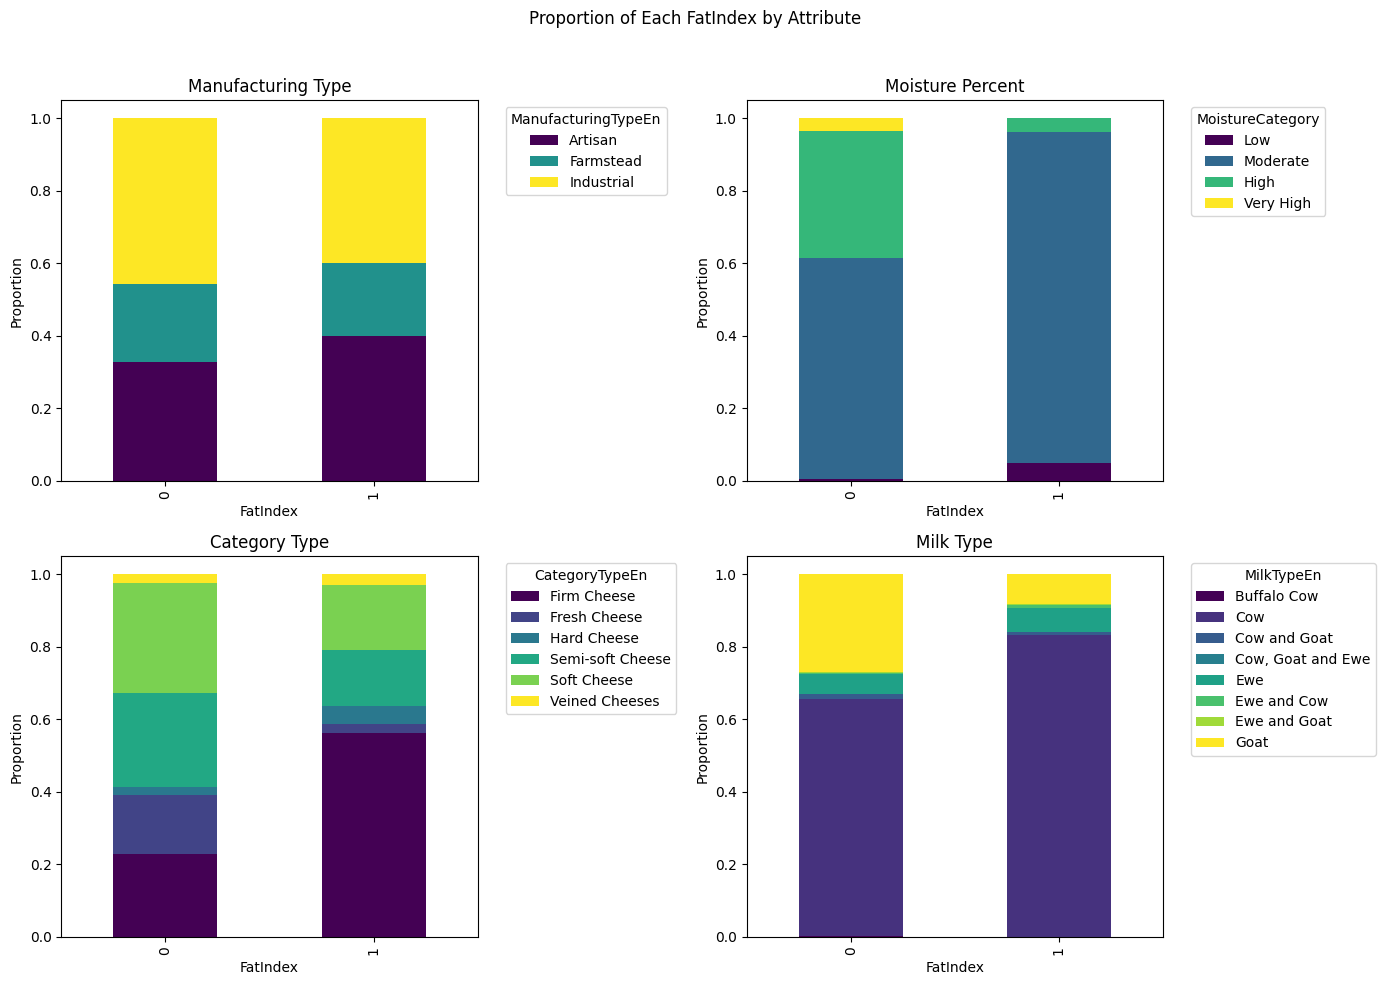

In [34]:
# Categorize the dataframe by the FatIndex. Calculate the proportion of each FatIndex in the previous columns (ManufacturingTypeEn, MoisturePercent, CategoryTypeEn, MilkTypeEn)
# and present your results in a stacked bar chart.

# Calculating proportions within each FatIndex category for ManufacturingTypeEn, MoisturePercent (binned), CategoryTypeEn, MilkTypeEn
fatindex_grouped = cheese_data.groupby('FatIndex')

# ManufacturingTypeEn
manufacturing_type_proportion = fatindex_grouped['ManufacturingTypeEn'].value_counts(normalize=True).unstack(fill_value=0)

# MoisturePercent - Binning into categories
cheese_data['MoistureCategory'] = pd.cut(cheese_data["MoisturePercent"], bins=[0, 30, 50, 70, 100], labels=["Low", "Moderate", "High", "Very High"])
moisture_proportion = fatindex_grouped['MoistureCategory'].value_counts(normalize=True).unstack(fill_value=0)

# CategoryTypeEn
category_type_proportion = fatindex_grouped['CategoryTypeEn'].value_counts(normalize=True).unstack(fill_value=0)

# MilkTypeEn
milk_type_proportion = fatindex_grouped['MilkTypeEn'].value_counts(normalize=True).unstack(fill_value=0)

# Plotting the stacked bar chart for each category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Proportion of Each FatIndex by Attribute")

# ManufacturingTypeEn proportions
manufacturing_type_proportion.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap="viridis")
axes[0, 0].set_title("Manufacturing Type")
axes[0, 0].set_ylabel("Proportion")
axes[0, 0].legend(title="ManufacturingTypeEn", bbox_to_anchor=(1.05, 1))

# Moisture Percent proportions
moisture_proportion.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap="viridis")
axes[0, 1].set_title("Moisture Percent")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].legend(title="MoistureCategory", bbox_to_anchor=(1.05, 1))

# CategoryTypeEn proportions
category_type_proportion.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap="viridis")
axes[1, 0].set_title("Category Type")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend(title="CategoryTypeEn", bbox_to_anchor=(1.05, 1))

# MilkTypeEn proportions
milk_type_proportion.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap="viridis")
axes[1, 1].set_title("Milk Type")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend(title="MilkTypeEn", bbox_to_anchor=(1.05, 1))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [38]:
# Separate the MoisturePercent values into two intervals that have (approximately) the same number of cheese products in the dataset. Categorize the dataset based on MoistureIndex, FatIndex, ManufacturingTypeEn, MoisturePercent, CategoryTypeEn, MilkTypeEn and calculate the proportions of each category. Represent your results in a separate `DataFrame`.
# Copying the data to avoid modifying the original DataFrame
df = cheese_data.copy()

# Define a new column 'MoistureIndex' based on median split
median_moisture = df['MoisturePercent'].median()
df['MoistureIndex'] = df['MoisturePercent'].apply(lambda x: 'Low Moisture' if x <= median_moisture else 'High Moisture')

# Group by the specified columns and count occurrences of each group
grouped_counts = df.groupby(['MoistureIndex', 'FatIndex', 'ManufacturingTypeEn', 'CategoryTypeEn', 'MilkTypeEn']).size()

# Reset index to flatten the grouped DataFrame and make proportions calculation easier
counts_df = grouped_counts.reset_index(name='Count')
total_counts = counts_df.groupby('MoistureIndex')['Count'].transform('sum')
counts_df['Proportion'] = counts_df['Count'] / total_counts

# Displaying the resulting DataFrame
counts_df 

,MoistureIndex,FatIndex,ManufacturingTypeEn,CategoryTypeEn,MilkTypeEn,Count,Proportion
0,High Moisture,0,Artisan,Firm Cheese,Cow,7,0.013972
1,High Moisture,0,Artisan,Fresh Cheese,Cow,15,0.029940
2,High Moisture,0,Artisan,Fresh Cheese,Ewe,7,0.013972
3,High Moisture,0,Artisan,Fresh Cheese,Goat,12,0.023952
4,High Moisture,0,Artisan,Semi-soft Cheese,Cow,28,0.055888
...,...,...,...,...,...,...,...
129,Low Moisture,1,Industrial,Semi-soft Cheese,Cow,8,0.015444
130,Low Moisture,1,Industrial,Semi-soft Cheese,Goat,2,0.003861
131,Low Moisture,1,Industrial,Soft Cheese,Cow,7,0.013514
132,Low Moisture,1,Industrial,Soft Cheese,Ewe,1,0.001931


**Explain your approach and assumptions once this section is completed.**
At first, by calculating the proportion of each desired value, we made pie diagrams.Next, Categorized the dataframe by the FatIndex and shown by bar chart.in the next, categorezed database in new frame that wanted.

# 3. Business Analyst Job Listings  

## 3.1 Loading Phase

As we will learn further in the course, a considerable source of data is free internet information which is crawled!

4092 business analyst job listings scraped from glassdoor are provided at `data/Q3`. Load the data in a `DataFrame`

In [40]:
business_df = pd.read_csv("data/Q3/BusinessAnalyst.csv")

## 3.2 Cleaning Phase

Perform the following actions on the dataset.

1. Describe the type and the value range of each attribute.  
2. Indicate and transform the attributes that are `Categorical`.
3. Replace **Salary Estimate** column with expected salary.
4. Explore lower and upper bounds of **Ratings** column. Fix any inconsitensies.
5. Provide a numerical column for expected company size.

In [61]:
# 1. Describe the type and the value range of each attribute.  

business_info = business_df.describe(include='all').T
business_info['data_type'] = business_df.dtypes
business_info

,count,unique,top,freq,data_type
Unnamed: 0,4092,3962,Business Analyst,16,object
index,4092,3706,$50K-$78K (Glassdoor est.),30,object
Job Title,4092,2210,Business Analyst,502,object
Salary Estimate,4092,167,$48K-$87K (Glassdoor est.),60,object
Job Description,4092,3732,"Staffigo Technical Services, LLC\n5.0",22,object
Rating,4092,41,"Jacksonville, FL",392,object
Company Name,4092,2197,"Staffigo Technical Services, LLC\n5.0",156,object
Location,4092,218,"San Diego, CA",348,object
Headquarters,4092,625,-1,316,object
Size,4092,17,10000+ employees,717,object


In [62]:
# 2. Indicate and transform the attributes that are `Categorical`.

categorical_columns = [
    'Job Title', 'Company Name', 'Location', 'Headquarters', 'Size', 
    'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply'
]

# Applying one-hot encoding to the categorical columns for a more interpretable transformation
business_df_onehot = pd.get_dummies(business_df, columns=categorical_columns, drop_first=True)

# Displaying
data_onehot_shape = business_df_onehot.shape
data_onehot_head = business_df_onehot.head()

data_onehot_shape, data_onehot_head

((4092, 5957),
   Unnamed: 0 index              Salary Estimate  \
 0          0     0  $56K-$102K (Glassdoor est.)   
 1          1     1  $56K-$102K (Glassdoor est.)   
 2          2     2  $56K-$102K (Glassdoor est.)   
 3          3     3  $56K-$102K (Glassdoor est.)   
 4          4     4  $56K-$102K (Glassdoor est.)   
 
                                      Job Description Rating Founded  \
 0  Company Overview\n\n\nAt Memorial Sloan Ketter...    3.9    1884   
 1  We are seeking for an energetic and collaborat...    3.8      -1   
 2  For more than a decade, Asembia has been worki...    3.6    2004   
 3  Job Description Summary\nThe Information Secur...    3.6    1897   
 4  Magnite is the world's largest independent sel...    3.4    2007   
 
    Job Title_#104293 Business Tech Support Analyst  \
 0                                            False   
 1                                            False   
 2                                            False   
 3               

In [63]:
# 3. Replace **Salary Estimate** column with expected salary.

def extract_expected_salary(salary_str):
    # Extracts the average of the salary range if present, otherwise returns None.
    match = re.findall(r'\$(\d+K)-\$(\d+K)', salary_str)
    if match:
        lower, upper = match[0]
        # Convert 'K' notation to numbers and compute average
        lower = int(lower.replace('K', '')) * 1000
        upper = int(upper.replace('K', '')) * 1000
        return (lower + upper) / 2
    return None

# Apply the function to the Salary Estimate column
business_df_onehot['Expected Salary'] = business_df_onehot['Salary Estimate'].apply(extract_expected_salary)

# Dropping the original Salary Estimate column
business_df_onehot.drop(columns=['Salary Estimate'], inplace=True)

# Verificaiton
business_df_onehot[['Expected Salary']].head()

,Expected Salary
0,79000.0
1,79000.0
2,79000.0
3,79000.0
4,79000.0


In [64]:
# 4. Explore lower and upper bounds of **Ratings** column. Fix any inconsitensies.

# Converting the Ratings column to numeric, coercing errors to NaN for non-numeric entries
business_df_onehot['Rating'] = pd.to_numeric(business_df_onehot['Rating'], errors='coerce')

# Replacing -1 and other NaN values with the median rating for a neutral, consistent fill
median_rating = business_df_onehot['Rating'].median()
business_df_onehot['Rating'].fillna(median_rating, inplace=True)
business_df_onehot['Rating'] = business_df_onehot['Rating'].clip(lower=1.0, upper=5.0)  # Ensuring bounds are within 1 and 5

# Showing consistency by rechekcing the unique values
business_df_onehot['Rating'].unique()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27320\3508118344.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  business_df_onehot['Rating'].fillna(median_rating, inplace=True)


array([3.9, 3.8, 3.6, 3.4, 4.2, 4.4, 4.1, 3.1, 3.7, 4.7, 4. , 5. , 3.2,
       3.5, 4.8, 4.3, 3. , 4.5, 3.3, 2.7, 2.8, 1. , 4.6, 2.6, 2.9, 2.5,
       2. , 4.9, 2.2, 2.3, 2.4, 1.7, 2.1, 1.9])

In [73]:
# 5. Provide a numerical column for expected company size.
# Function to map size categories to approximate numeric values
def map_size(size):
    size_mapping = {
        '1 to 50 employees': 25,
        '51 to 200 employees': 125,
        '201 to 500 employees': 350,
        '501 to 1000 employees': 750,
        '1001 to 5000 employees': 3000,
        '5001 to 10000 employees': 7500,
        '10000+ employees': 10000,
        'Unknown': None  # Handle unknown sizes with NaN
    }
    return size_mapping.get(size, None)

# Apply the mapping function to create a new column for expected company size
business_df_onehot['Expected Company Size'] = business_df_onehot['Size'].apply(map_size)

# Display the first few rows to verify
business_df_onehot[['Expected Company Size']].head()


,Expected Company Size
0,25.0
1,NaN
2,10000.0
3,750.0


## 3.3 Querying Phase 

Answer the following queries using the functionality of `Pandas`.

1. Provide a pie chart of the job titles. What are the most two popular positions?
2. Consider three variables in one's interest in a job position : Salary, Size of the company and the city. Create 3 scatter plots of peoples' ratings vs. these three variables.
3. Is there any linear correlation evident in either of the plots? Configure your answers using `Scipy.stats`
4. Justify the following claim : "Higher salary causes more satisfaction towards the job".
5. Extract each and every word out of Job Description. Append all of the words and filter them in order to keep the adjectives (Hint: You may perform this filtering using the English adjective corpus provided at `data/Q3`).
6. Create a wordcloud image out of the filtered words (`pip install wordcloud`). What are the main capabilities one must posses in order to hold an Analyst position in the US?

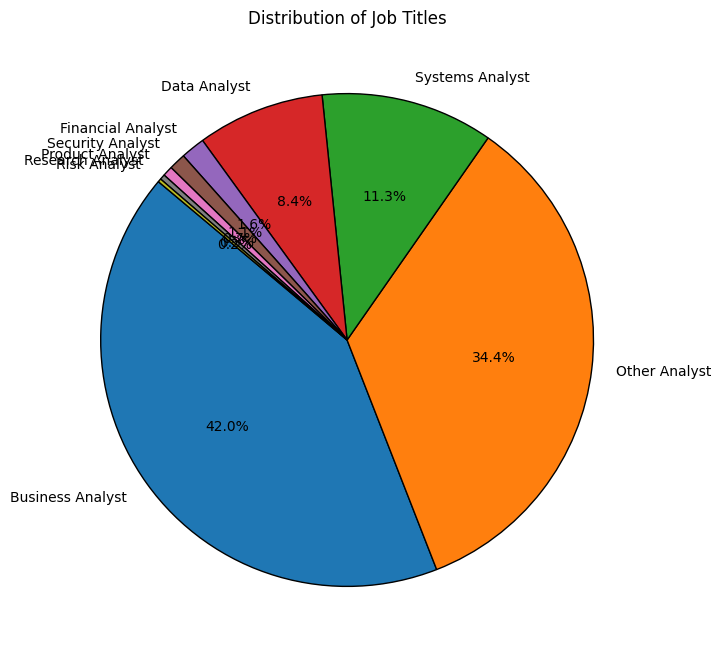

Job Category
Business Analyst    1720
Other Analyst       1407
Name: count, dtype: int64

In [86]:
# Define a function to categorize same job titles together
def categorize_job_title(title):
    title = title.lower()
    if 'business analyst' in title:
        return 'Business Analyst'
    elif 'data analyst' in title:
        return 'Data Analyst'
    elif 'financial analyst' in title or 'fp&a' in title:
        return 'Financial Analyst'
    elif 'information security' in title or 'security analyst' in title:
        return 'Security Analyst'
    elif 'systems analyst' in title or 'system analyst' in title:
        return 'Systems Analyst'
    elif 'product analyst' in title:
        return 'Product Analyst'
    elif 'risk analyst' in title:
        return 'Risk Analyst'
    elif 'research analyst' in title:
        return 'Research Analyst'
    else:
        return 'Other Analyst'

# Apply the categorization function
business_df['Job Category'] = business_df['Job Title'].apply(categorize_job_title)

# Count occurrences in each job category for the pie chart
job_category_counts = business_df['Job Category'].value_counts()

# Plotting the pie chart for job categories
plt.figure(figsize=(10, 8))
job_category_counts.plot.pie(autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Job Titles')
plt.ylabel('')  # Hide y-label for better visualization
plt.show()

# Displaying the most common job categories for verification
job_category_counts.head(2)



**Explain your approach and assumptions once this section is completed.**

In [79]:
from scipy.stats import pearsonr

# Dropping rows with NaN values in relevant columns for each pairwise correlation calculation
salary_data = business_df_onehot[['Expected Salary', 'Rating']].dropna()

# Correlation between Rating and Expected Salary
salary_corr, salary_pval = pearsonr(salary_data['Expected Salary'], salary_data['Rating'])

# Correlation between Rating and Expected Company Size
size_data = business_df_onehot[['Expected Company Size', 'Rating']].dropna()
size_corr, size_pval = pearsonr(size_data['Expected Company Size'], size_data['Rating'])

# Correlation between Rating and City Encoded
city_data = business_df_onehot[['City Encoded', 'Rating']].dropna()
city_corr, city_pval = pearsonr(city_data['City Encoded'], city_data['Rating'])

salary_corr, salary_pval, size_corr, size_pval, city_corr, city_pval


KeyError: "None of [Index(['Expected Salary', 'Rating'], dtype='object')] are in the [columns]"

In [78]:
# Load the list of adjectives from the provided file
with open('data/Q3/adjectives.txt', 'r') as file:
    adjectives_list = file.read().splitlines()

# Convert adjectives to a set for faster lookup
adjectives_set = set(adjectives_list)

# Combine all job descriptions into one string
job_descriptions_combined = " ".join(business_df['Job Description'].astype(str).tolist())

# Extract all words from the descriptions
all_words = re.findall(r'\b\w+\b', job_descriptions_combined.lower())

# Filter for adjectives using the provided list
adjectives_in_descriptions = [word for word in all_words if word in adjectives_set]

# Display the first 10 adjectives as a sample
# adjectives_in_descriptions[:10]

# Define a list of common non-adjective words that may have been captured incorrectly
common_words_to_remove = {'the', 'only', 'and', 'to', 'of', 'in', 'for', 'a', 'an', 'on', 'by', 'at', 'with'}

# Filter out these common words from the list of extracted adjectives
filtered_adjectives = [word for word in adjectives_in_descriptions if word not in common_words_to_remove]

# Display the first 10 filtered adjectives as a sample
filtered_adjectives[:10]

['changing',
 'working',
 'forward',
 'improving',
 'top',
 'proud',
 'one',
 'great',
 'work',
 'well']

In [85]:
from wordcloud import WordCloud

# Create a single string from the filtered adjectives for word cloud generation
text_for_wordcloud = " ".join(filtered_adjectives)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', font_path='data/Q3/times.ttf').generate(text_for_wordcloud)

# Display the generated word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.title("Key Attributes for Analyst Positions (Filtered Adjectives)")
plt.show()


ModuleNotFoundError: No module named 'wordcloud'

# 4. Covid in the US
In this question, you are required to reproduce the graphs shown in a real journalistic article. After all, reproducibility is an important part of professional journalism as well as data science. Also, a great deal of a data scientist's work is to communicate data in a way that anyone with any level of expertise in the field would understand.

You should reproduce the 4 graphs shown in <a href="https://projects.fivethirtyeight.com/coronavirus-polls/"> this article</a>. The data is openly accessible through <a href="https://github.com/fivethirtyeight/covid-19-polls/"> FiveThirtyEight's github</a>. Nevertheless, both the data and the article are available in `data` folder in case of unstable internet connections!

*Note: Your graphs don't have to be as interactive or detailed as the ones on the website. Only showing the averages, some (not all) data points with light color, legends, titles, x values, and y values are necessary.*

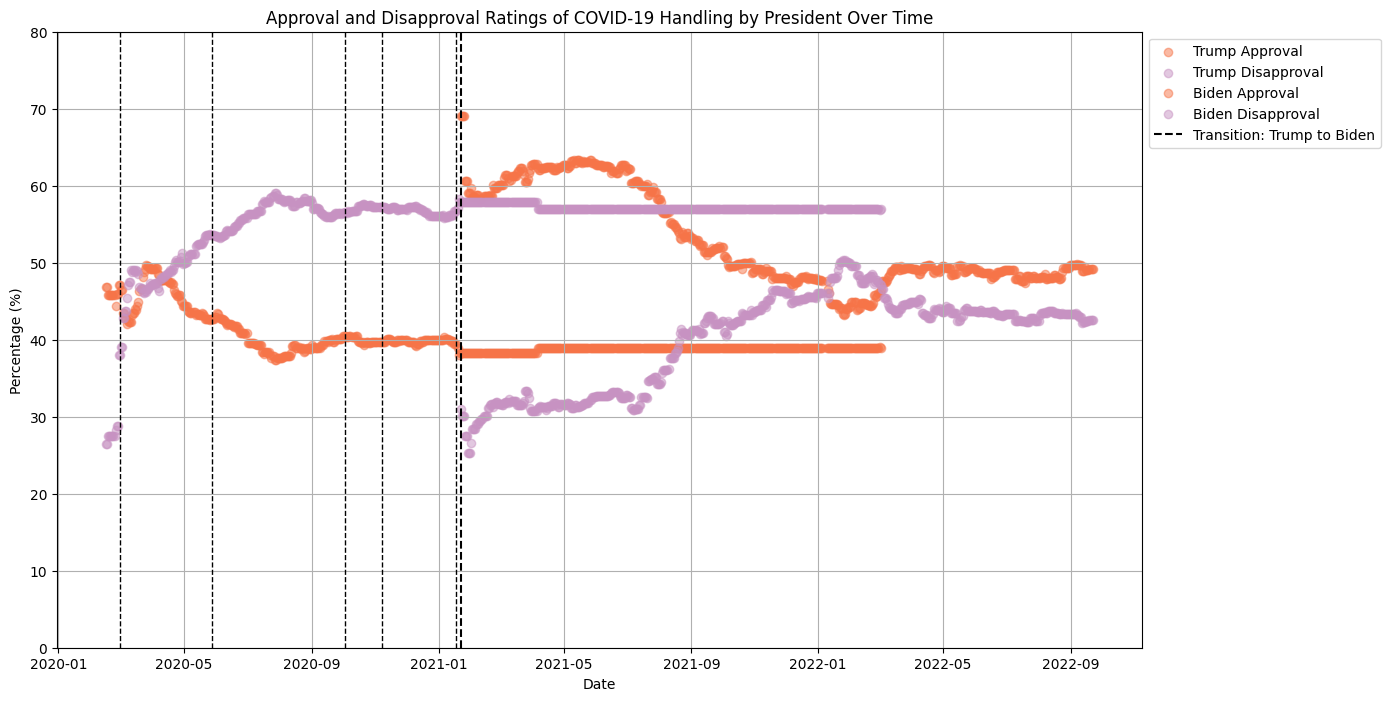

In [82]:
# Loading the daily averages data from covid_approval_toplines.csv
toplines_data = pd.read_csv('data/Q4/covid/covid-19-polls-master/covid_approval_toplines.csv')

# Filtering data for overall population (party == 'all')
toplines_all = toplines_data[toplines_data['party'] == 'all'].copy()

# Converting 'modeldate' column to datetime format for proper time series plotting
toplines_all['modeldate'] = pd.to_datetime(toplines_all['modeldate'], errors='coerce')

# Adjusting the date range
start_date = pd.to_datetime("2020-02-16")
end_date = pd.to_datetime("2022-11-10")
transition_date = pd.to_datetime("2021-01-22")

# Defining the updated important dates for the first graph
important_dates_first_graph = [
    pd.to_datetime("2020-02-29"),  # First U.S. death reported
    pd.to_datetime("2020-05-28"),  # U.S. deaths surpass 100,000
    pd.to_datetime("2020-10-03"),  # Trump diagnosed with COVID-19
    pd.to_datetime("2020-11-07"),  # Biden declared election winner
    pd.to_datetime("2021-01-18")   # Biden sworn into office
]

# Filtering the data for the specified date range for the first graph
toplines_all_filtered = toplines_all[(toplines_all['modeldate'] >= start_date) & (toplines_all['modeldate'] <= end_date)]

# Re-filtering Trump and Biden sections within the specified date range
trump_section = toplines_all_filtered[toplines_all_filtered['modeldate'] < transition_date]
biden_section = toplines_all_filtered[toplines_all_filtered['modeldate'] >= transition_date]

# Plotting the first graph with the updated specifications
plt.figure(figsize=(14, 8))

# Scatter plots for Trump and Biden sections
plt.scatter(trump_section['modeldate'], trump_section['approve_estimate'], color='#f67448', alpha=0.5, label="Trump Approval")
plt.scatter(trump_section['modeldate'], trump_section['disapprove_estimate'], color='#c792c2', alpha=0.5, label="Trump Disapproval")
plt.scatter(biden_section['modeldate'], biden_section['approve_estimate'], color='#f67448', alpha=0.5, label="Biden Approval")
plt.scatter(biden_section['modeldate'], biden_section['disapprove_estimate'], color='#c792c2', alpha=0.5, label="Biden Disapproval")


# Adding vertical dashed lines for the important dates
for date in important_dates_first_graph:
    plt.axvline(x=date, color='black', linestyle='--', linewidth=1)

# Adding the Transition line
plt.axvline(x=transition_date, color='black', linestyle='--', linewidth=1.5, label="Transition: Trump to Biden")

# Setting y-axis limit and labels
plt.ylim(0, 80)
plt.title("Approval and Disapproval Ratings of COVID-19 Handling by President Over Time")
plt.xlabel("Date")
plt.ylabel("Percentage (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

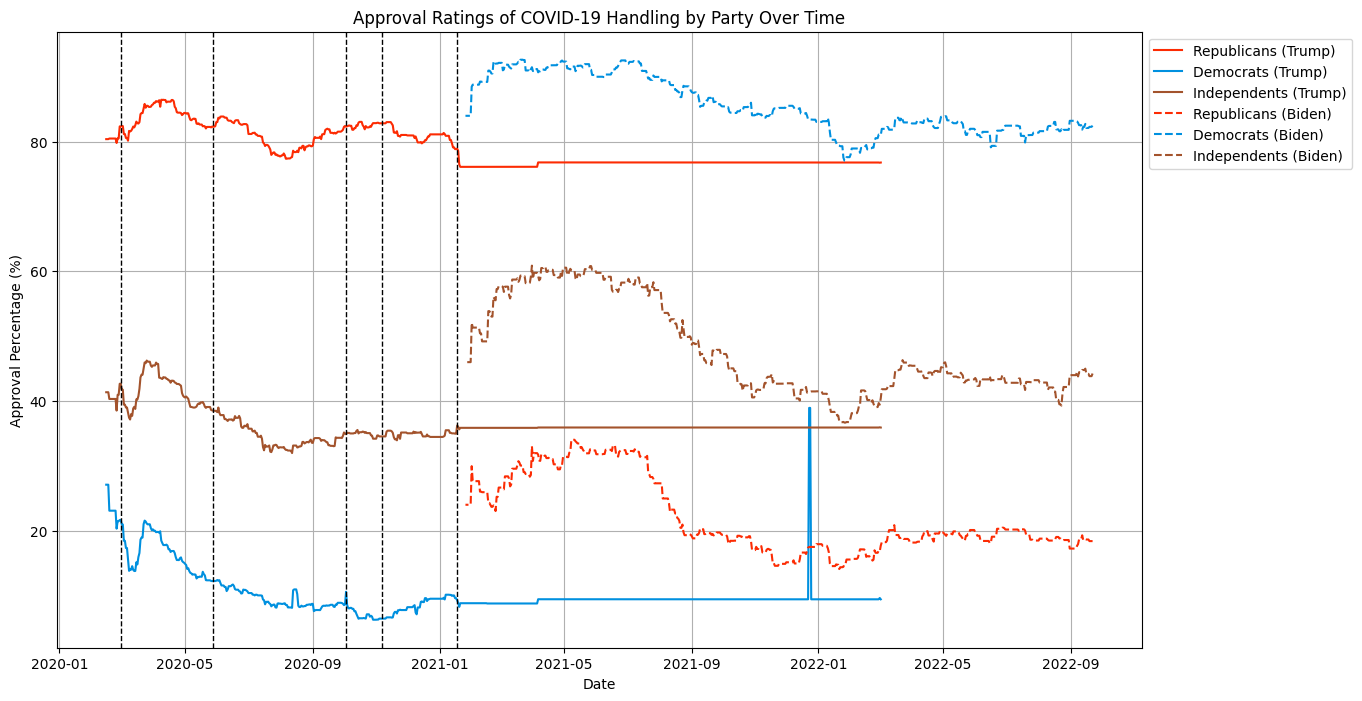

In [84]:
# Loading the data from covid_approval_toplines.csv
toplines_data = pd.read_csv('data/Q4/covid/covid-19-polls-master/covid_approval_toplines.csv')

# Filtering Trump data for each party
trump_republican = toplines_data.loc[(toplines_data['party'] == 'R') & (toplines_data['subject'] == 'Trump')].copy()
trump_democrat = toplines_data.loc[(toplines_data['party'] == 'D') & (toplines_data['subject'] == 'Trump')].copy()
trump_independent = toplines_data.loc[(toplines_data['party'] == 'I') & (toplines_data['subject'] == 'Trump')].copy()

# Filtering Biden data for each party
biden_republican = toplines_data.loc[(toplines_data['party'] == 'R') & (toplines_data['subject'] == 'Biden')].copy()
biden_democrat = toplines_data.loc[(toplines_data['party'] == 'D') & (toplines_data['subject'] == 'Biden')].copy()
biden_independent = toplines_data.loc[(toplines_data['party'] == 'I') & (toplines_data['subject'] == 'Biden')].copy()

# Convert 'modeldate' to datetime format
trump_republican['modeldate'] = pd.to_datetime(trump_republican['modeldate'], errors='coerce')
trump_democrat['modeldate'] = pd.to_datetime(trump_democrat['modeldate'], errors='coerce')
trump_independent['modeldate'] = pd.to_datetime(trump_independent['modeldate'], errors='coerce')
biden_republican['modeldate'] = pd.to_datetime(biden_republican['modeldate'], errors='coerce')
biden_democrat['modeldate'] = pd.to_datetime(biden_democrat['modeldate'], errors='coerce')
biden_independent['modeldate'] = pd.to_datetime(biden_independent['modeldate'], errors='coerce')

# Defining the important dates for vertical dashed lines
important_dates_second_graph = [
    pd.to_datetime("2020-02-29"),  # First U.S. death reported
    pd.to_datetime("2020-05-28"),  # U.S. deaths surpass 100,000
    pd.to_datetime("2020-10-03"),  # Trump diagnosed with COVID-19
    pd.to_datetime("2020-11-07"),  # Biden declared election winner
    pd.to_datetime("2021-01-18")   # Biden sworn into office
]

# Plotting the second graph with important dates
plt.figure(figsize=(14, 8))

# Plot Trump's approval ratings by party
plt.plot(trump_republican['modeldate'], trump_republican['approve_estimate'], color='#fc2b03', label="Republicans (Trump)")
plt.plot(trump_democrat['modeldate'], trump_democrat['approve_estimate'], color='#0090df', label="Democrats (Trump)")
plt.plot(trump_independent['modeldate'], trump_independent['approve_estimate'], color='#a3532c', label="Independents (Trump)")

# Plot Biden's approval ratings by party with dashed lines
plt.plot(biden_republican['modeldate'], biden_republican['approve_estimate'], color='#fc2b03', linestyle="--", label="Republicans (Biden)")
plt.plot(biden_democrat['modeldate'], biden_democrat['approve_estimate'], color='#0090df', linestyle="--", label="Democrats (Biden)")
plt.plot(biden_independent['modeldate'], biden_independent['approve_estimate'], color='#a3532c', linestyle="--", label="Independents (Biden)")

# Adding vertical dashed lines for the important dates
for date in important_dates_second_graph:
    plt.axvline(x=date, color='black', linestyle='--', linewidth=1)

# Adding labels, title, and legend
plt.title("Approval Ratings of COVID-19 Handling by Party Over Time")
plt.xlabel("Date")
plt.ylabel("Approval Percentage (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Positioning the legend outside the upper right corner
plt.grid(True)
plt.show()

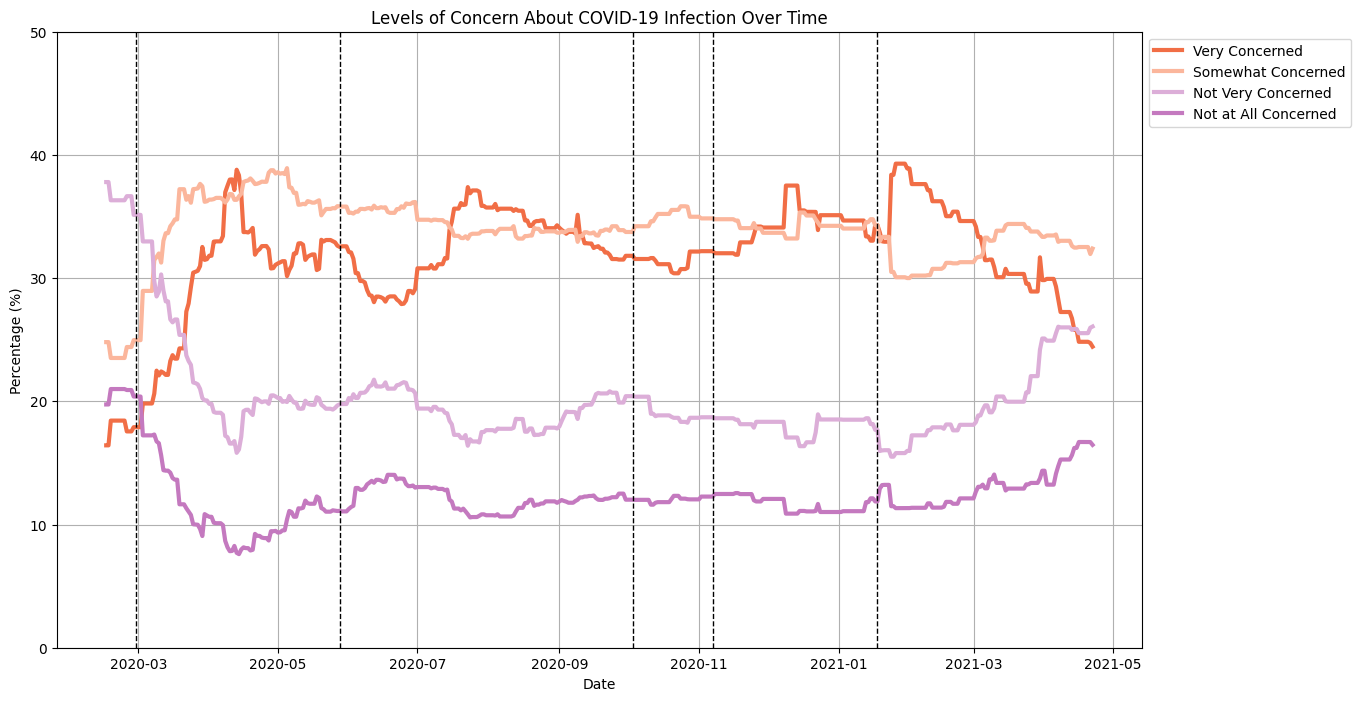

In [65]:
# Loading the data from covid_concern_toplines.csv
concern_toplines = pd.read_csv('data/Q4/covid/covid-19-polls-master/covid_concern_toplines.csv')

# Filtering data for "concern-infected" as an example to reproduce the graph with levels of concern over time
concern_infected = concern_toplines[concern_toplines['subject'] == 'concern-infected'].copy()

# Converting 'modeldate' column to datetime format
concern_infected['modeldate'] = pd.to_datetime(concern_infected['modeldate'], errors='coerce')

# Defining the updated date range
start_date = pd.to_datetime("2020-02-16")
end_date = pd.to_datetime("2021-04-22")

# Filtering the data to fit within the specified date range
concern_infected_filtered = concern_infected[(concern_infected['modeldate'] >= start_date) & (concern_infected['modeldate'] <= end_date)]

# Defining the updated important dates with their corresponding events
important_dates = [
    pd.to_datetime("2020-02-29"),  # First U.S. death reported
    pd.to_datetime("2020-05-28"),  # U.S. deaths surpass 100,000
    pd.to_datetime("2020-10-03"),  # Trump diagnosed with COVID-19
    pd.to_datetime("2020-11-07"),  # Biden declared election winner
    pd.to_datetime("2021-01-18")   # Biden sworn into office
]

# Defining colors as specified
color_somewhat = "#fbb69c"
color_very = "#f16e46"
color_not_at_all = "#c479bf"
color_not_very = "#dcaed8"

plt.figure(figsize=(14, 8))

# Plot each concern level with thicker lines and specified colors
plt.plot(concern_infected_filtered['modeldate'], concern_infected_filtered['very_estimate'], color=color_very, linewidth=3, label="Very Concerned")
plt.plot(concern_infected_filtered['modeldate'], concern_infected_filtered['somewhat_estimate'], color=color_somewhat, linewidth=3, label="Somewhat Concerned")
plt.plot(concern_infected_filtered['modeldate'], concern_infected_filtered['not_very_estimate'], color=color_not_very, linewidth=3, label="Not Very Concerned")
plt.plot(concern_infected_filtered['modeldate'], concern_infected_filtered['not_at_all_estimate'], color=color_not_at_all, linewidth=3, label="Not at All Concerned")

# Adding vertical dashed lines for important dates
for date in important_dates:
    plt.axvline(x=date, color='black', linestyle='--', linewidth=1)

# Adding labels, title, and moving legend outside the upper-right corner
plt.ylim(0, 50) 
plt.title("Levels of Concern About COVID-19 Infection Over Time")
plt.xlabel("Date")
plt.ylabel("Percentage (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Positioning the legend outside
plt.grid(True)
plt.show()

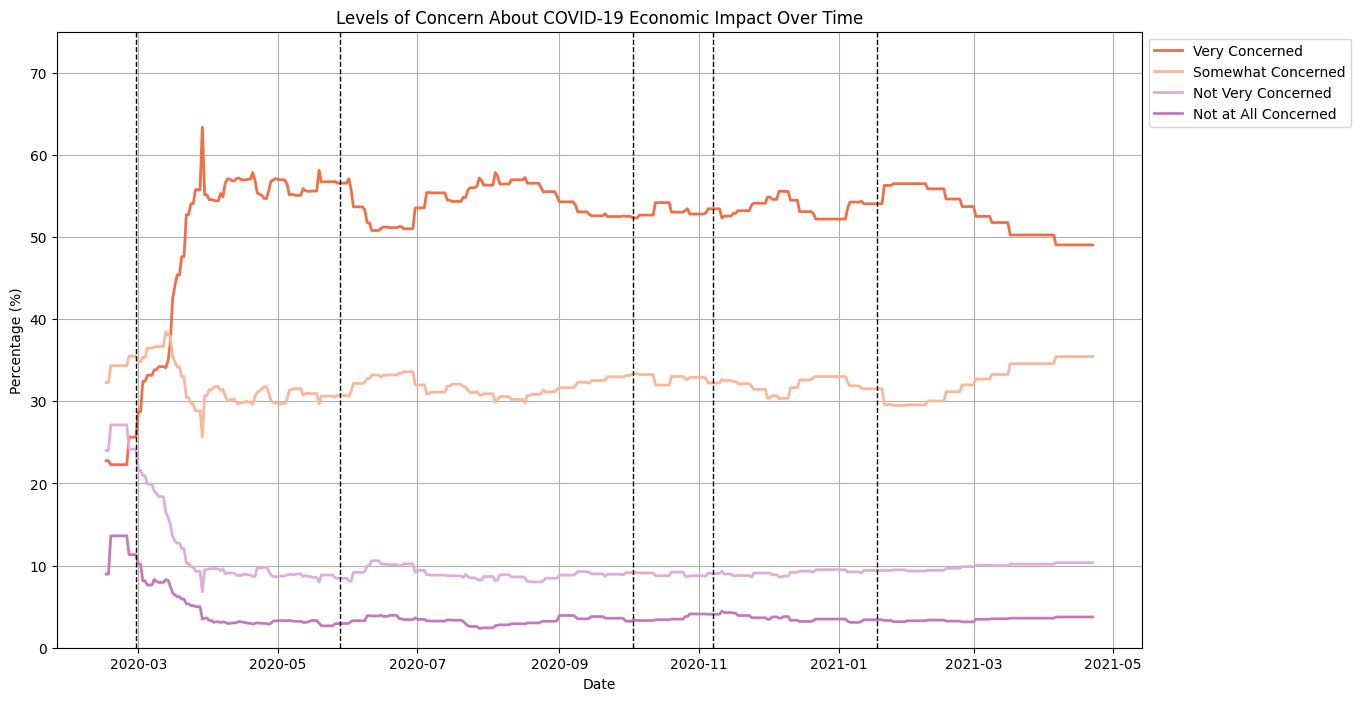

In [66]:
# Filtering data for "concern-economy" to reproduce the fourth graph with levels of concern over time
concern_economy = concern_toplines[concern_toplines['subject'] == 'concern-economy'].copy()

# Converting 'modeldate' column to datetime format
concern_economy['modeldate'] = pd.to_datetime(concern_economy['modeldate'], errors='coerce')

# Filtering the data to fit within the specified date range (from February 16, 2020, to April 22, 2021)
concern_economy_filtered = concern_economy[(concern_economy['modeldate'] >= start_date) & (concern_economy['modeldate'] <= end_date)]

plt.figure(figsize=(14, 8))

# Plot each concern level with thicker lines and specified colors
plt.plot(concern_economy_filtered['modeldate'], concern_economy_filtered['very_estimate'], color=color_very, linewidth=2, label="Very Concerned")
plt.plot(concern_economy_filtered['modeldate'], concern_economy_filtered['somewhat_estimate'], color=color_somewhat, linewidth=2, label="Somewhat Concerned")
plt.plot(concern_economy_filtered['modeldate'], concern_economy_filtered['not_very_estimate'], color=color_not_very, linewidth=2, label="Not Very Concerned")
plt.plot(concern_economy_filtered['modeldate'], concern_economy_filtered['not_at_all_estimate'], color=color_not_at_all, linewidth=2, label="Not at All Concerned")

# Adding vertical dashed lines for important dates
for date in important_dates:
    plt.axvline(x=date, color='black', linestyle='--', linewidth=1)

# Adding labels, title, and setting y-axis limit
plt.ylim(0, 75)  # Setting y-axis limit to 50%
plt.title("Levels of Concern About COVID-19 Economic Impact Over Time")
plt.xlabel("Date")
plt.ylabel("Percentage (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Positioning the legend outside
plt.grid(True)
plt.show()